# 🎵 Waveform + Mel Spectrogram 앙상블 모델

이 노트북에서는 Waveform과 Mel Spectrogram을 모두 사용하여 앙상블 모델을 구축하고, Vote 형식으로 예측합니다.

## 📋 목차
1. **상태별 특징 시각화**: Waveform과 Mel Spectrogram 특징 분석
2. **Waveform 기반 모델**: 1D CNN 모델
3. **Mel Spectrogram 기반 모델**: 2D CNN 모델
4. **앙상블 모델**: 두 모델의 예측을 Vote로 결합
5. **성능 평가**: 앙상블 모델의 정확도 비교

In [1]:
# ============================================================
# 필수 라이브러리 임포트
# ============================================================

import os
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter, defaultdict
import librosa
import librosa.display

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 공통 유틸리티
from utils import setup_plotting, get_data_dir, get_state_mapping, get_state_names

# 프로젝트 모듈
from app.ml.features.extractor import AudioFeatureExtractor, AudioConfig
from app.ml.training.trainer import Trainer, create_optimizer, create_scheduler

# 시각화 설정
setup_plotting()

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 라이브러리 로드 완료!")
print(f"🖥️ Device: {device}")


✅ 라이브러리 로드 완료!
🖥️ Device: cpu


---
## 1. 상태별 Waveform 특징 시각화


📊 총 데이터: 949개

📊 BRAKING 상태 - Waveform 특징


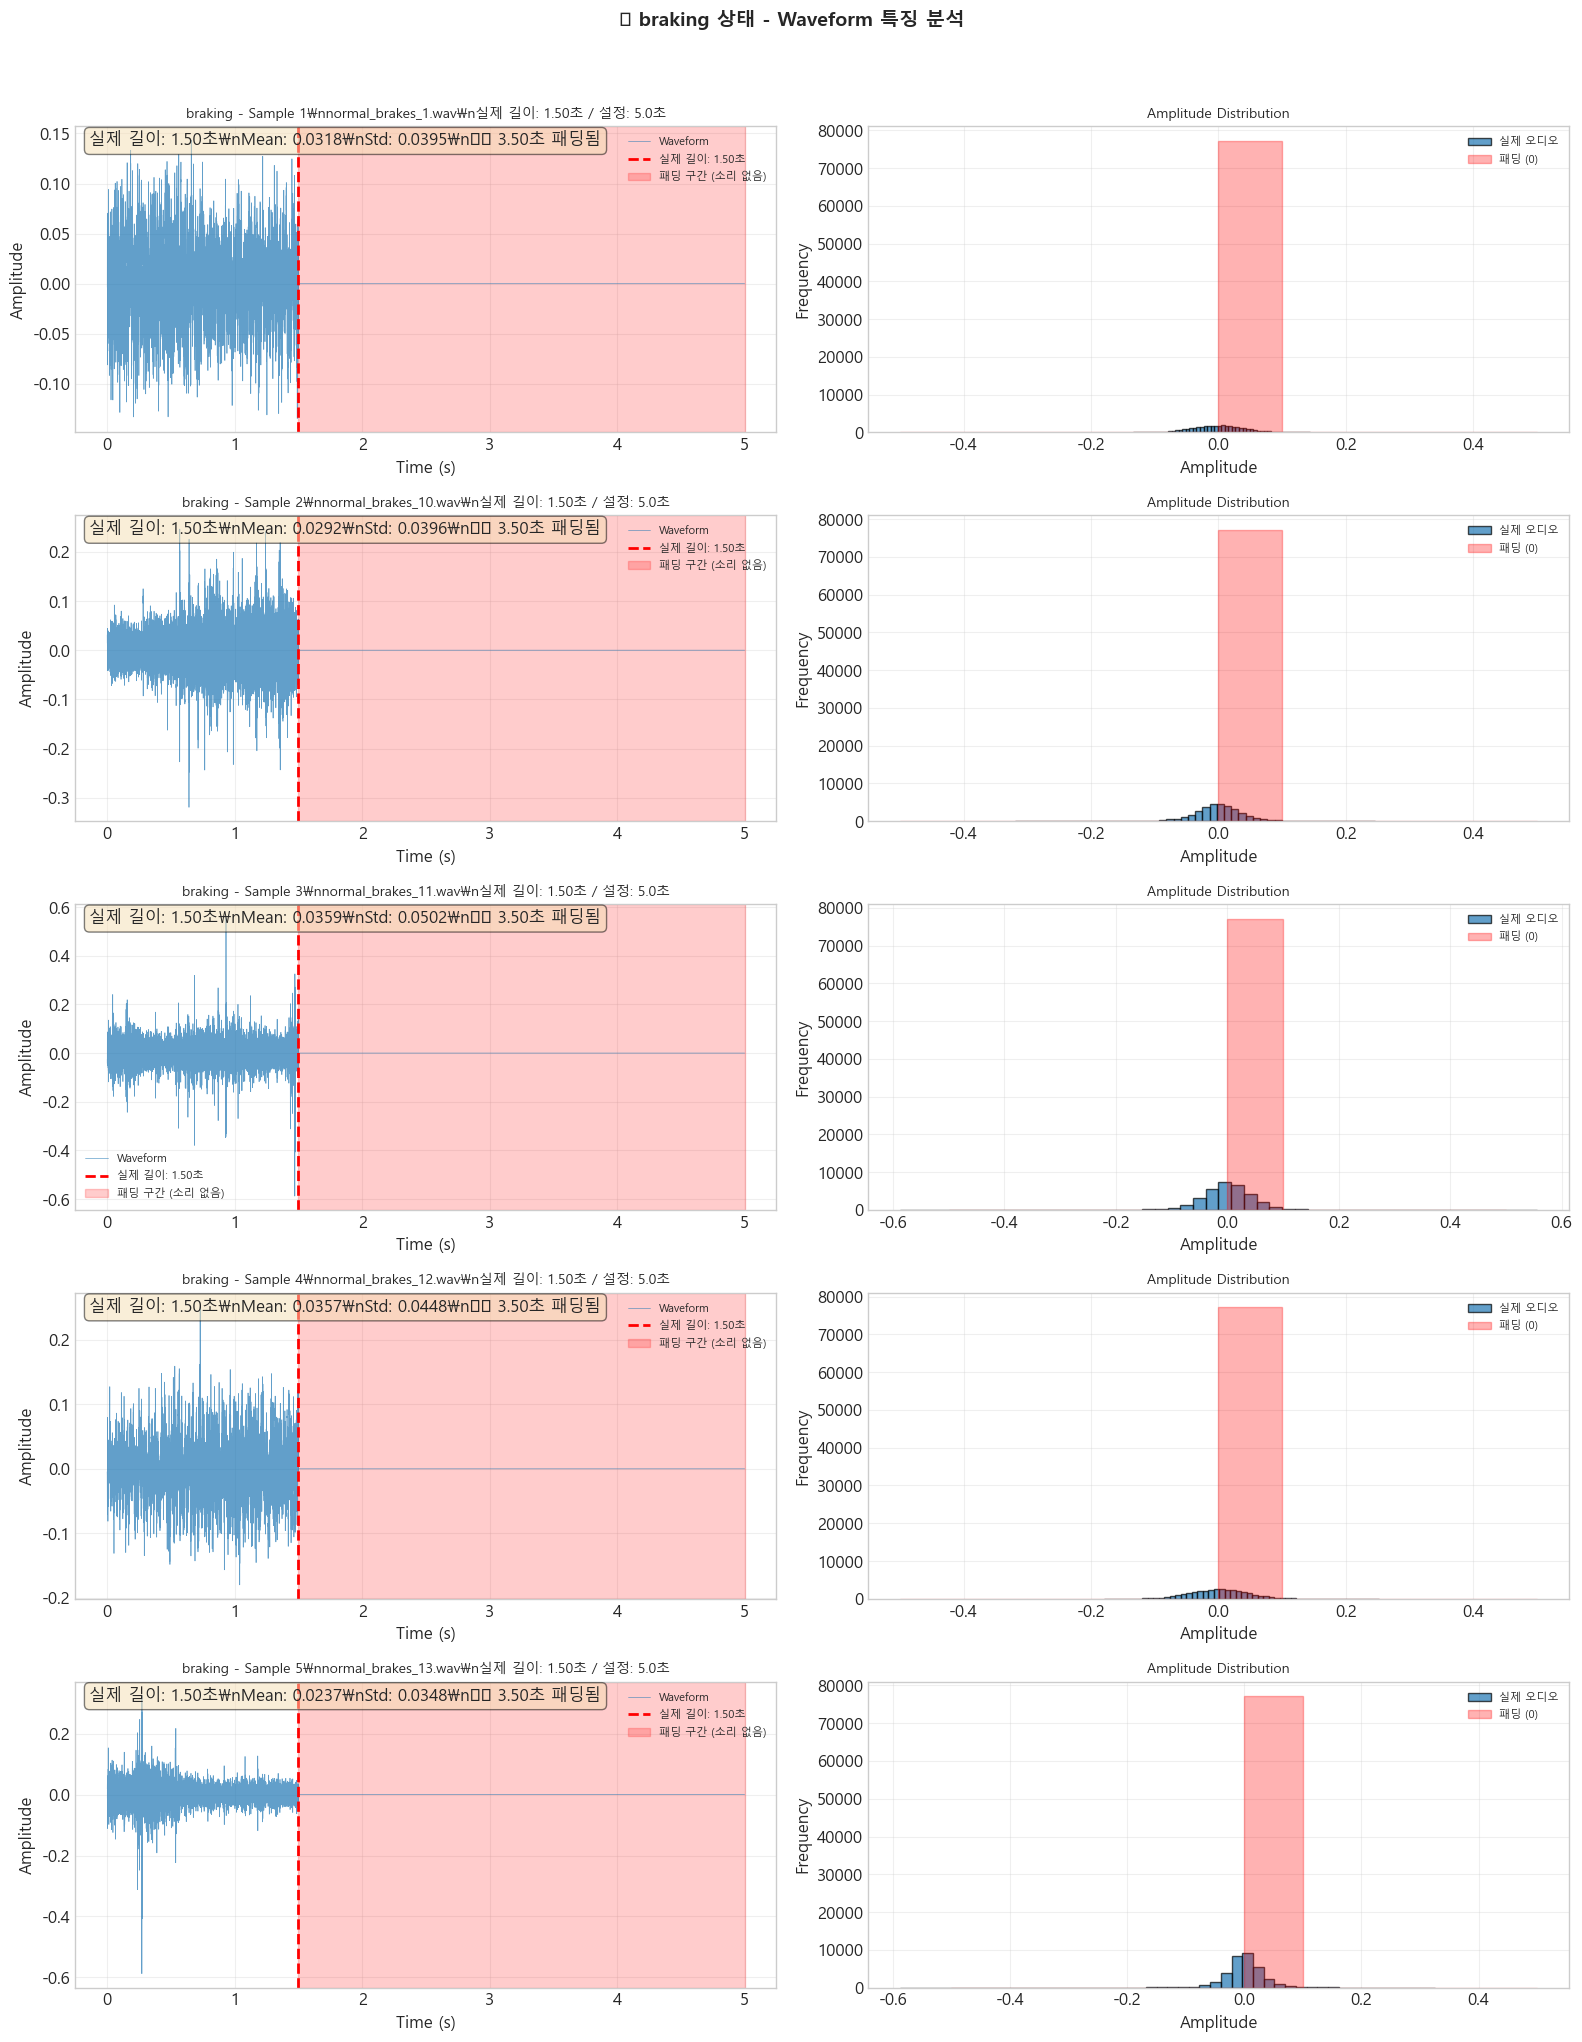


📊 IDLE 상태 - Waveform 특징


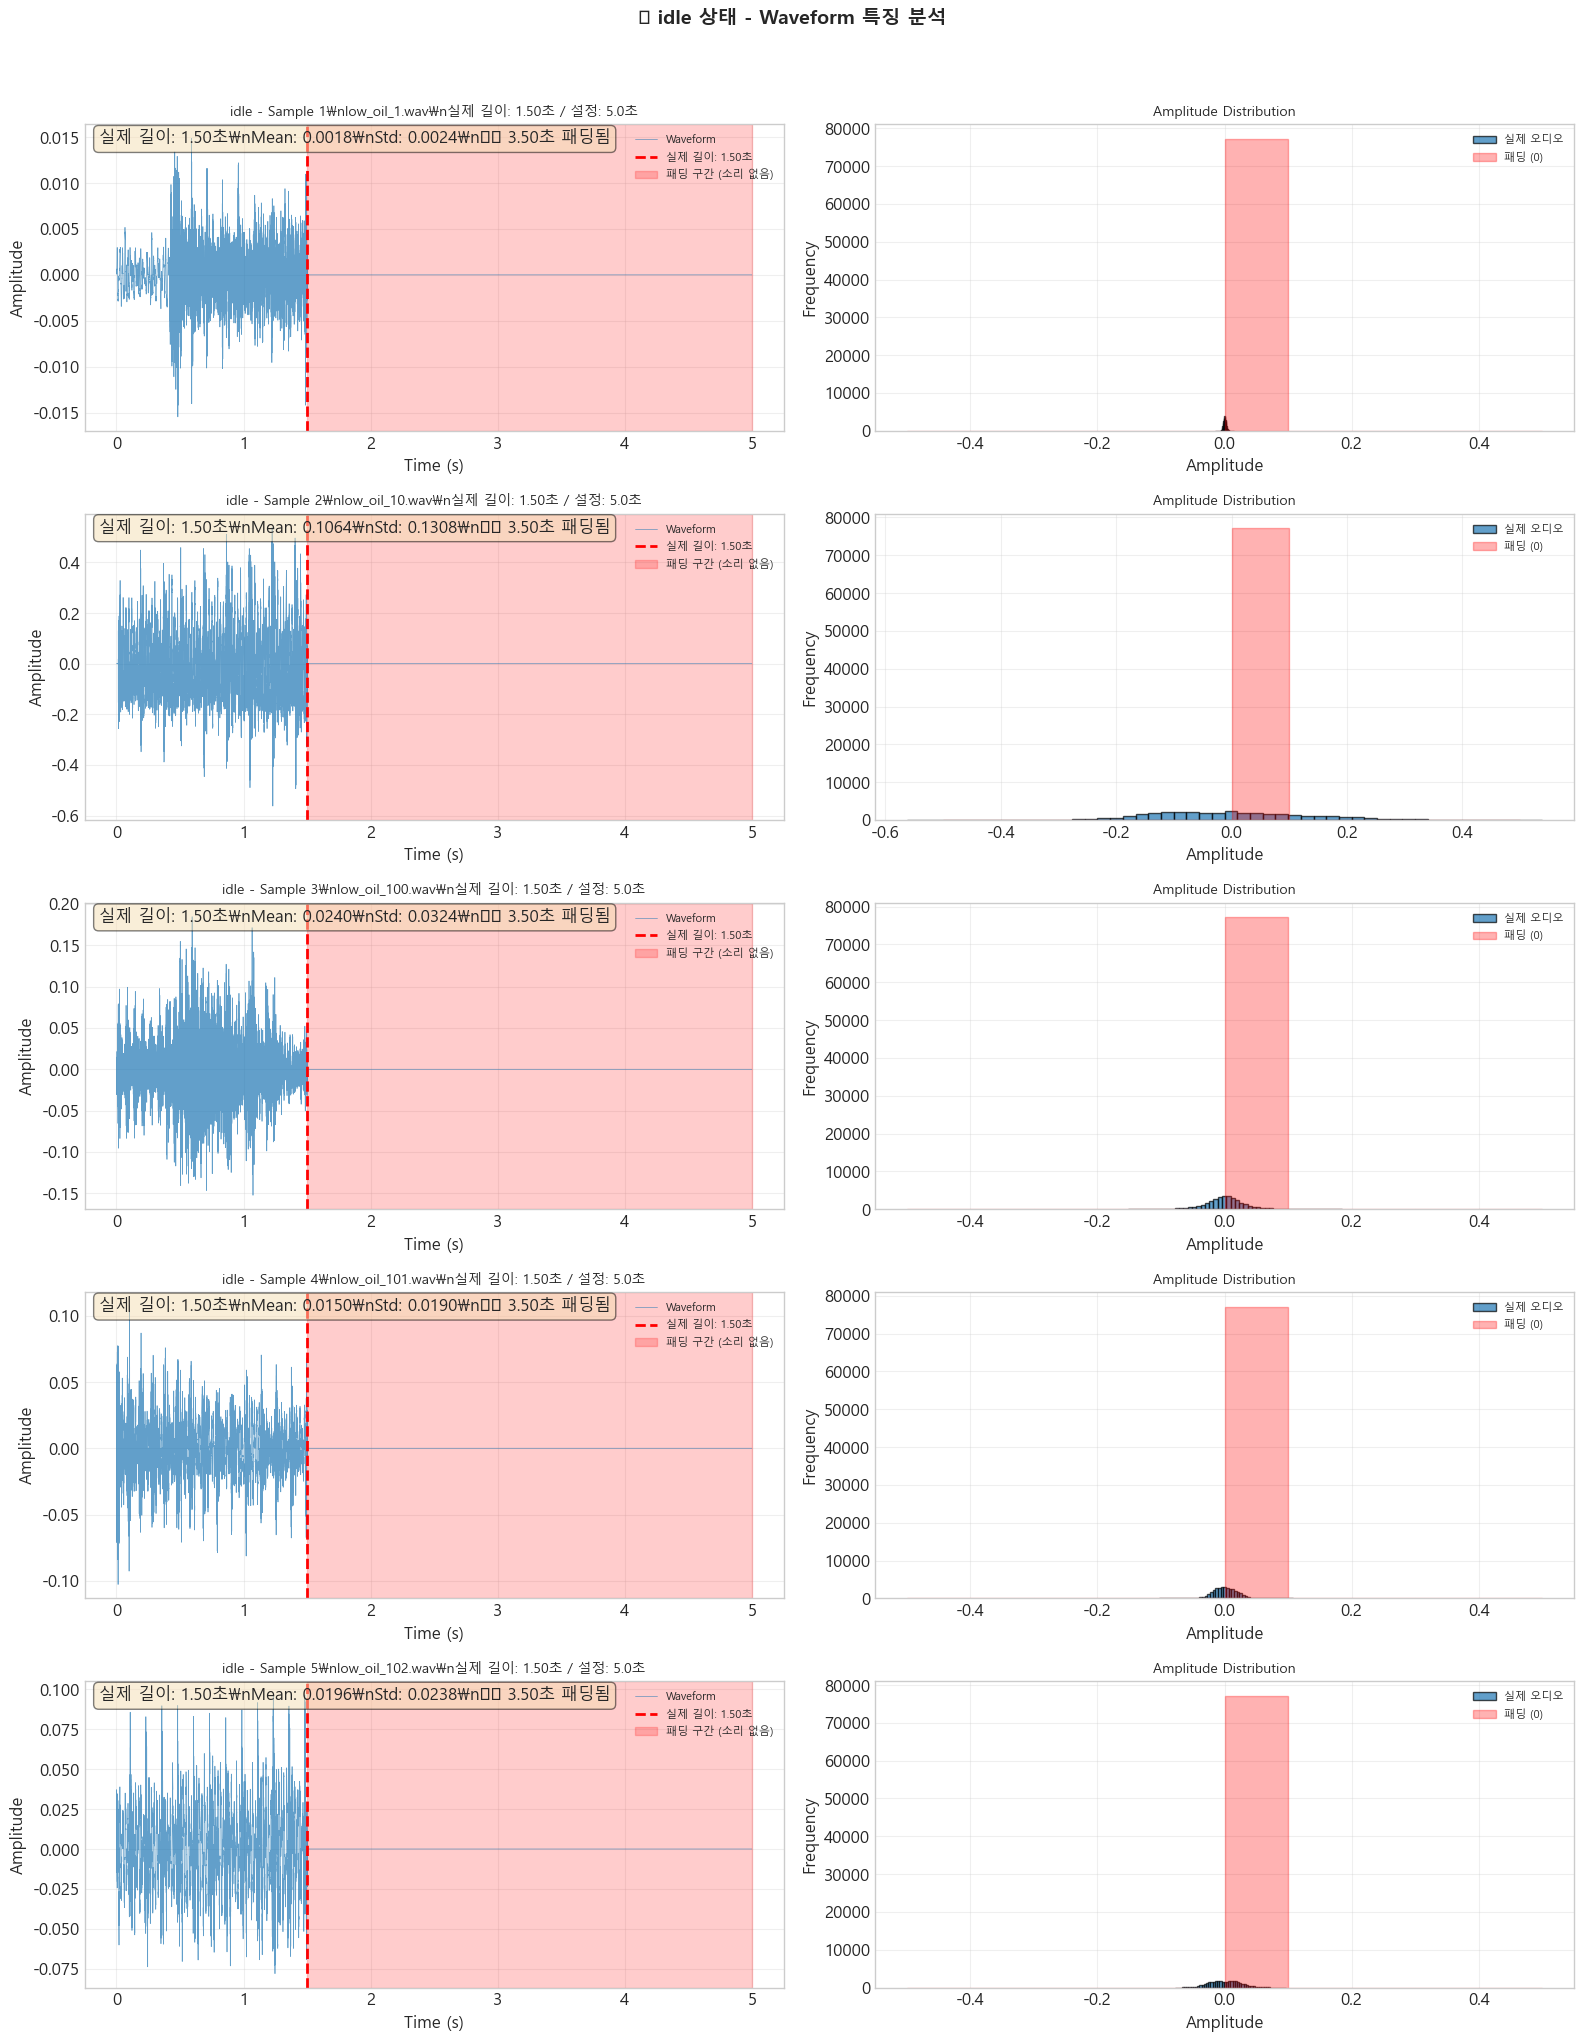


📊 STARTUP 상태 - Waveform 특징


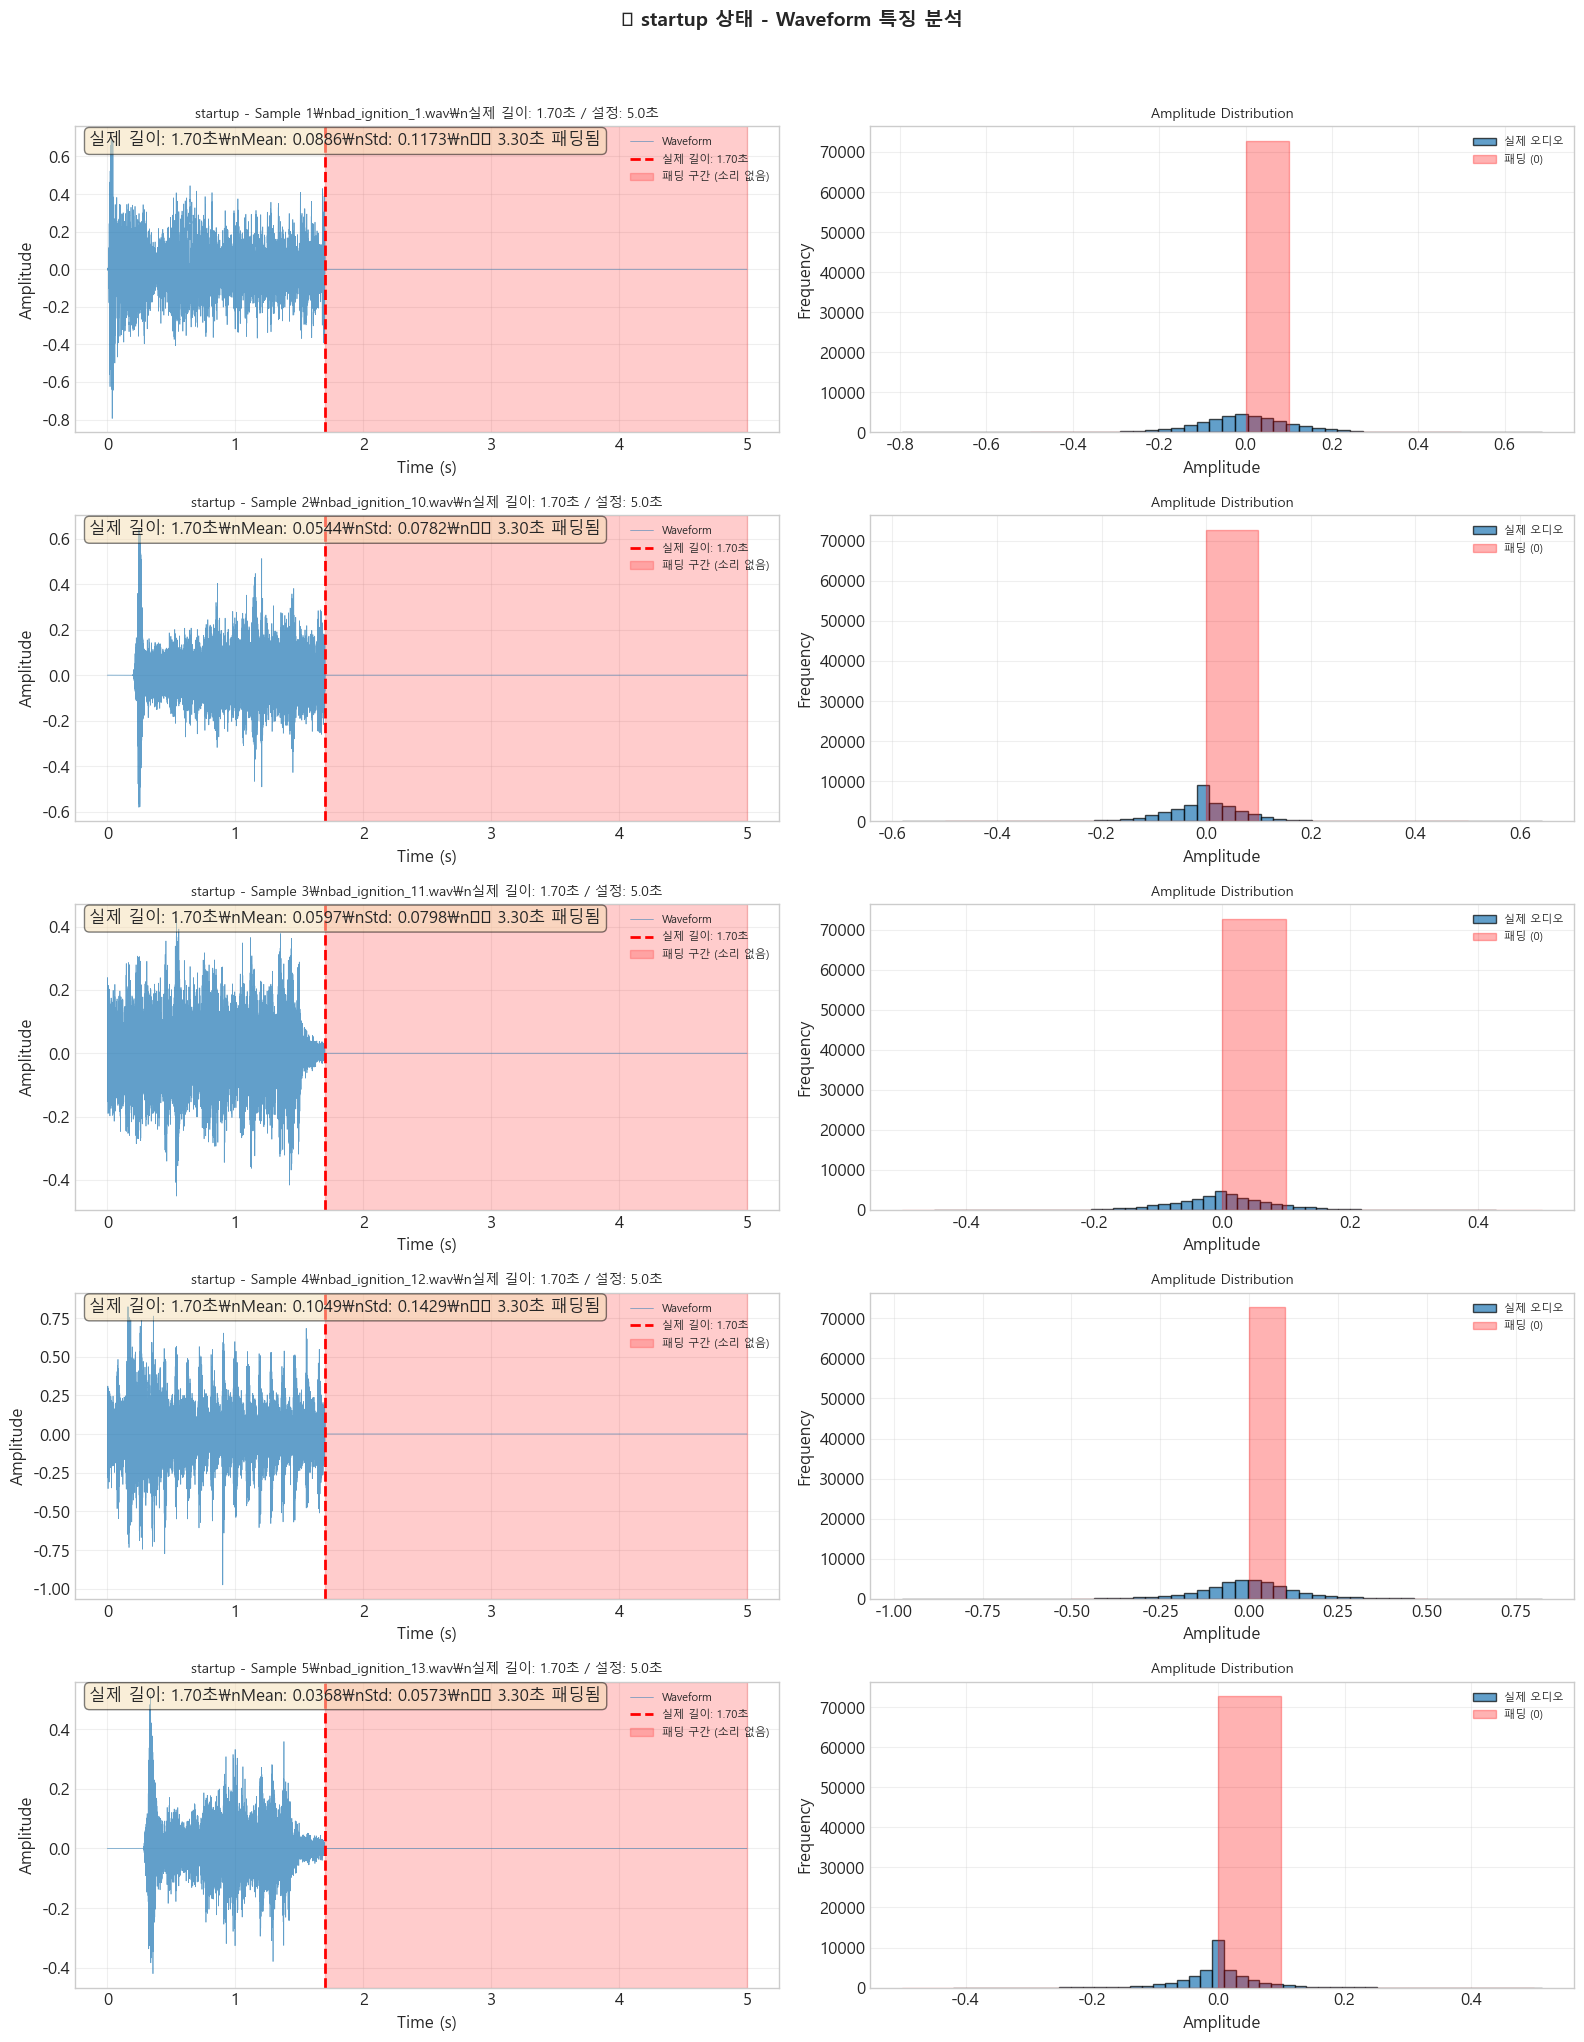

In [2]:
# ============================================================
# 데이터 로드 및 상태별 Waveform 특징 시각화
# ============================================================

data_dir = get_data_dir()
state_mapping = get_state_mapping()
state_names = get_state_names()

# 파일 경로 수집
all_files = []
all_states = []

for state_dir in sorted(data_dir.iterdir()):
    if not state_dir.is_dir() or state_dir.name == 'augmented':
        continue
    
    state_name = state_dir.name
    state_idx = state_mapping.get(state_name, -1)
    
    if state_idx == -1:
        continue
    
    for problem_dir in sorted(state_dir.iterdir()):
        if not problem_dir.is_dir() or problem_dir.name == 'combined':
            continue
        
        wav_files = list(problem_dir.glob('*.wav'))
        for f in wav_files:
            all_files.append(f)
            all_states.append(state_idx)

print(f"📊 총 데이터: {len(all_files)}개")

# 피처 추출기 초기화
audio_config = AudioConfig(sample_rate=22050, duration=5.0, n_mels=128, n_fft=2048, hop_length=512)
feature_extractor = AudioFeatureExtractor(config=audio_config)

# 상태별 샘플 선택
state_samples = defaultdict(list)
n_samples_per_state = 5

for file_path, state_idx in zip(all_files, all_states):
    if len(state_samples[state_idx]) < n_samples_per_state:
        state_samples[state_idx].append(file_path)

# 상태별 Waveform 시각화
for state_idx, state_name in enumerate(state_names):
    if state_idx not in state_samples:
        continue
    
    print(f"\n{'='*70}")
    print(f"📊 {state_name.upper()} 상태 - Waveform 특징")
    print(f"{'='*70}")
    
    fig, axes = plt.subplots(n_samples_per_state, 2, figsize=(16, 4 * n_samples_per_state))
    if n_samples_per_state == 1:
        axes = axes.reshape(1, -1)
    
    for idx, file_path in enumerate(state_samples[state_idx]):
        # 실제 오디오 길이 확인 (패딩 전)
        y_original, sr_original = librosa.load(str(file_path), sr=None)
        actual_duration = len(y_original) / sr_original
        
        # 패딩된 오디오 로드
        y, sr = feature_extractor.load_audio(str(file_path))
        time = np.linspace(0, len(y) / sr, len(y))
        
        # 실제 오디오 길이와 패딩 구간 구분
        actual_samples = int(actual_duration * sr)
        padding_start_idx = actual_samples
        
        # Waveform 시각화
        ax = axes[idx, 0]
        ax.plot(time, y, linewidth=0.5, alpha=0.7, label='Waveform')
        
        # 패딩 구간 표시
        if actual_duration < audio_config.duration:
            ax.axvline(x=actual_duration, color='red', linestyle='--', linewidth=2, 
                      label=f'실제 길이: {actual_duration:.2f}초')
            ax.axvspan(actual_duration, audio_config.duration, alpha=0.2, color='red', 
                      label='패딩 구간 (소리 없음)')
        
        ax.set_title(f'{state_name} - Sample {idx+1}\\n{file_path.name}\\n실제 길이: {actual_duration:.2f}초 / 설정: {audio_config.duration}초', 
                    fontsize=10)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
        # 통계 정보
        mean_amp = np.mean(np.abs(y[:actual_samples])) if actual_samples > 0 else 0
        std_amp = np.std(y[:actual_samples]) if actual_samples > 0 else 0
        
        # 실제 오디오 부분만 통계 계산
        info_text = f'실제 길이: {actual_duration:.2f}초\\nMean: {mean_amp:.4f}\\nStd: {std_amp:.4f}'
        if actual_duration < audio_config.duration:
            info_text += f'\\n⚠️ {audio_config.duration - actual_duration:.2f}초 패딩됨'
        
        ax.text(0.02, 0.98, info_text,
               transform=ax.transAxes, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 진폭 분포 (실제 오디오 부분만)
        ax = axes[idx, 1]
        if actual_samples > 0:
            ax.hist(y[:actual_samples], bins=50, alpha=0.7, edgecolor='black', label='실제 오디오')
            if padding_start_idx < len(y):
                ax.hist(y[padding_start_idx:], bins=10, alpha=0.3, color='red', 
                       edgecolor='red', label='패딩 (0)')
        else:
            ax.hist(y, bins=50, alpha=0.7, edgecolor='black')
        
        ax.set_title(f'Amplitude Distribution', fontsize=10)
        ax.set_xlabel('Amplitude')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        if actual_samples > 0 and padding_start_idx < len(y):
            ax.legend(fontsize=8)
    
    plt.suptitle(f'🔊 {state_name} 상태 - Waveform 특징 분석', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


---
## 2. 상태별 Mel Spectrogram 특징 시각화



📊 BRAKING 상태 - Mel Spectrogram 특징


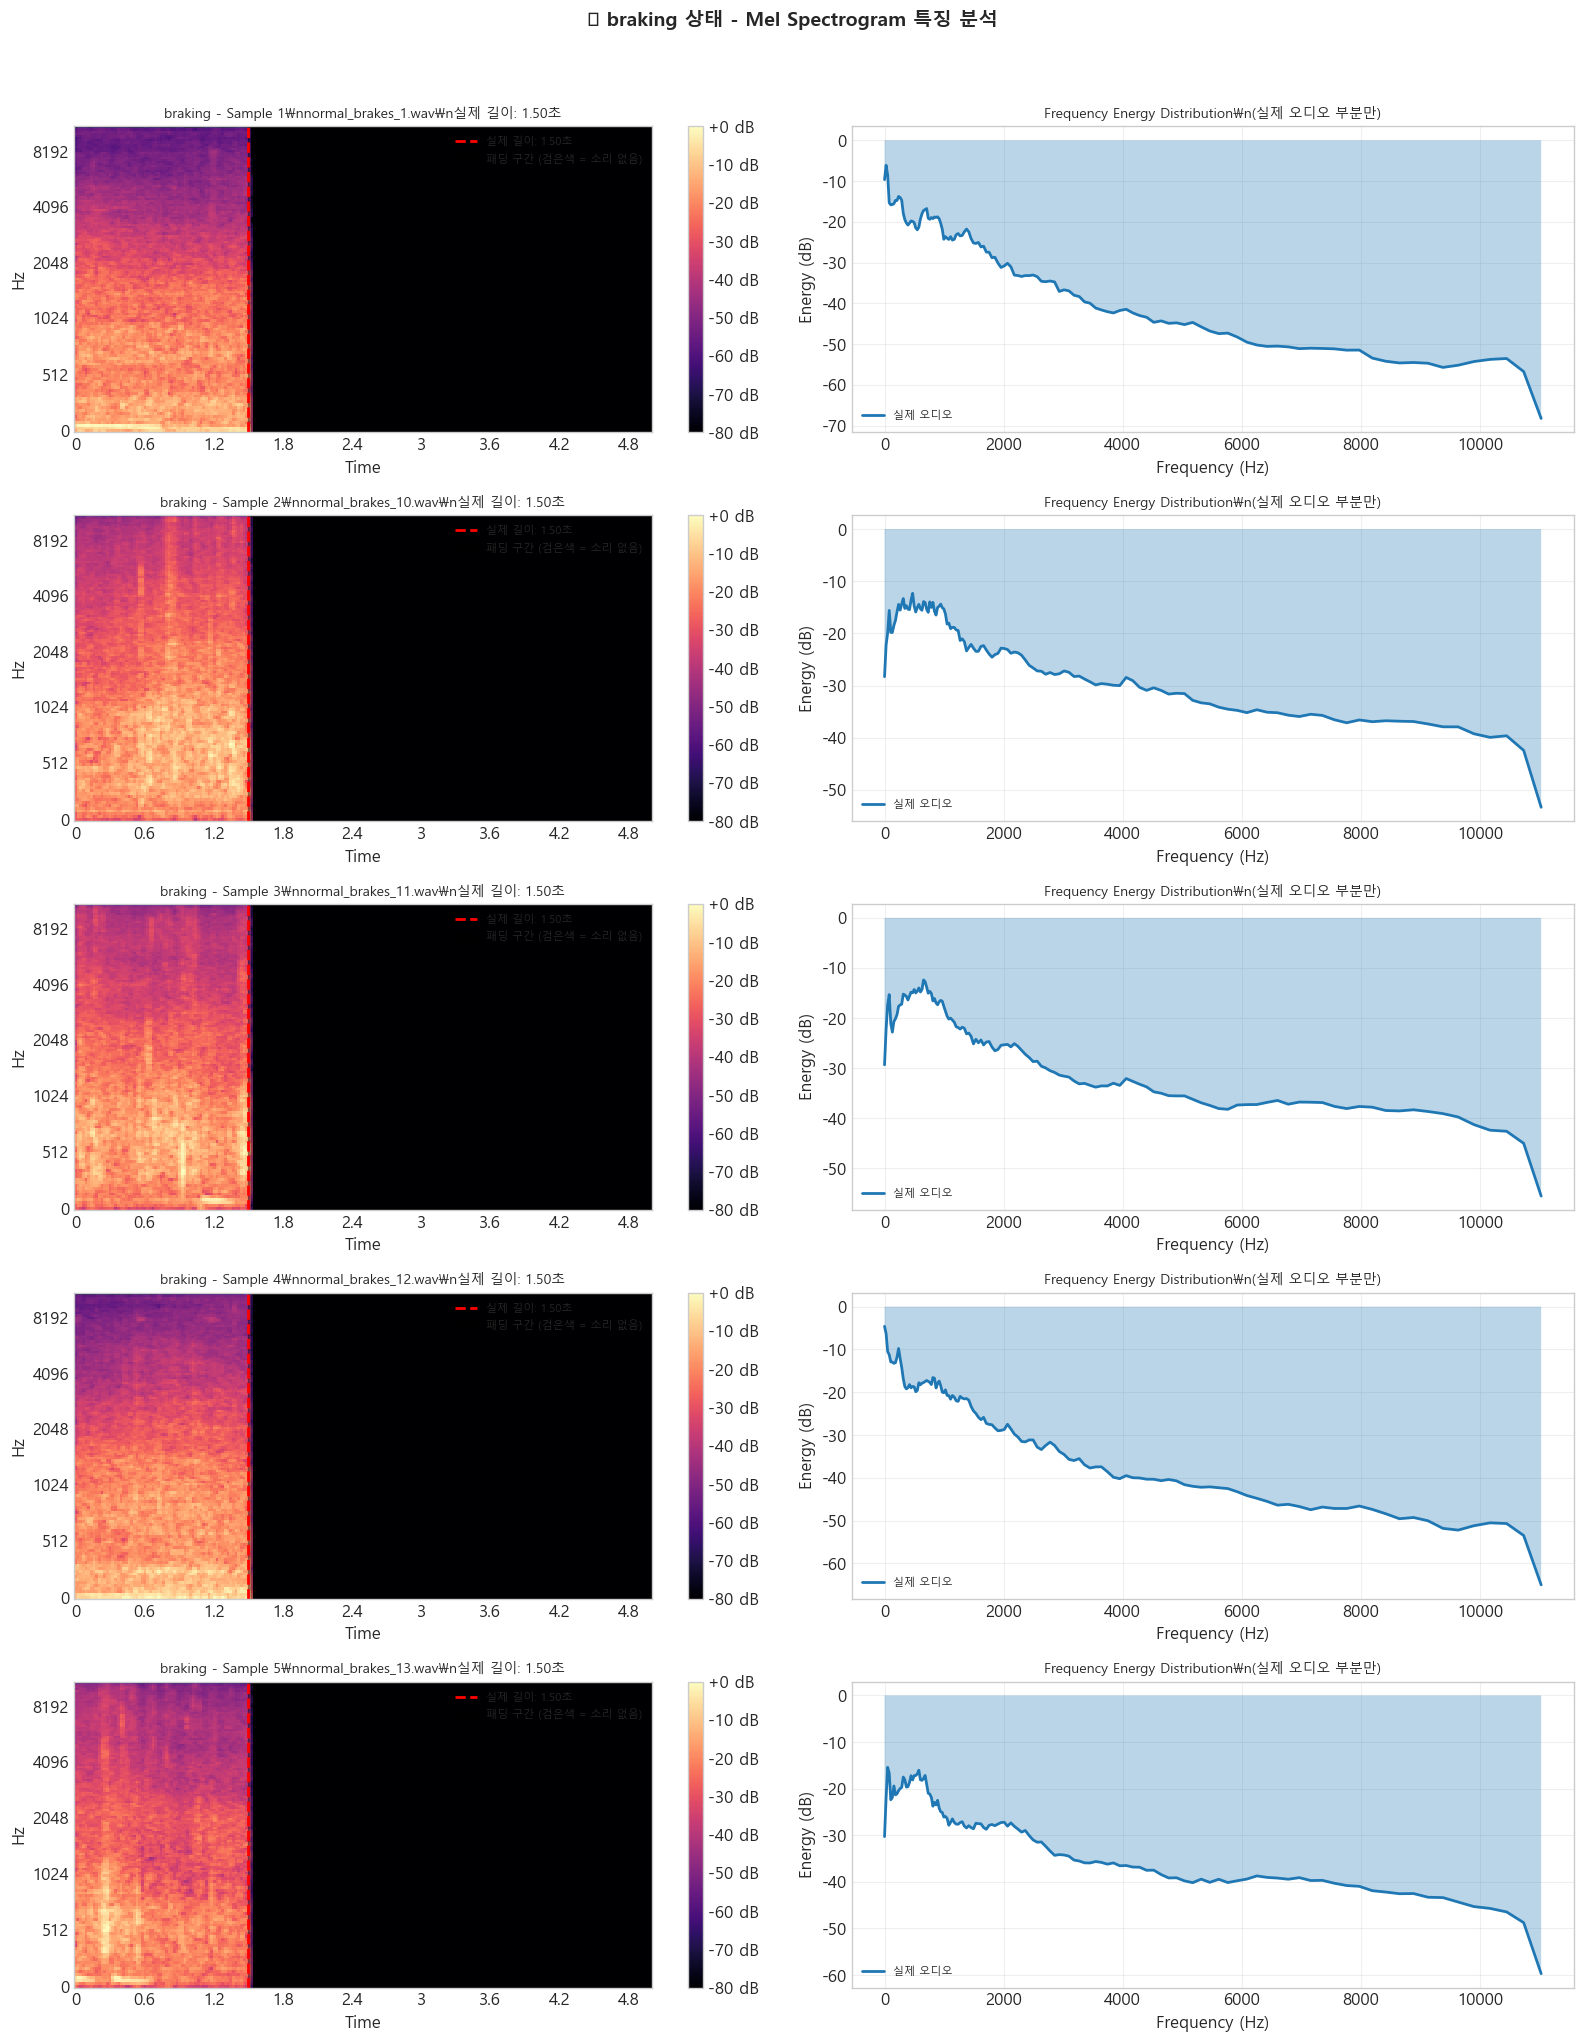


📊 IDLE 상태 - Mel Spectrogram 특징


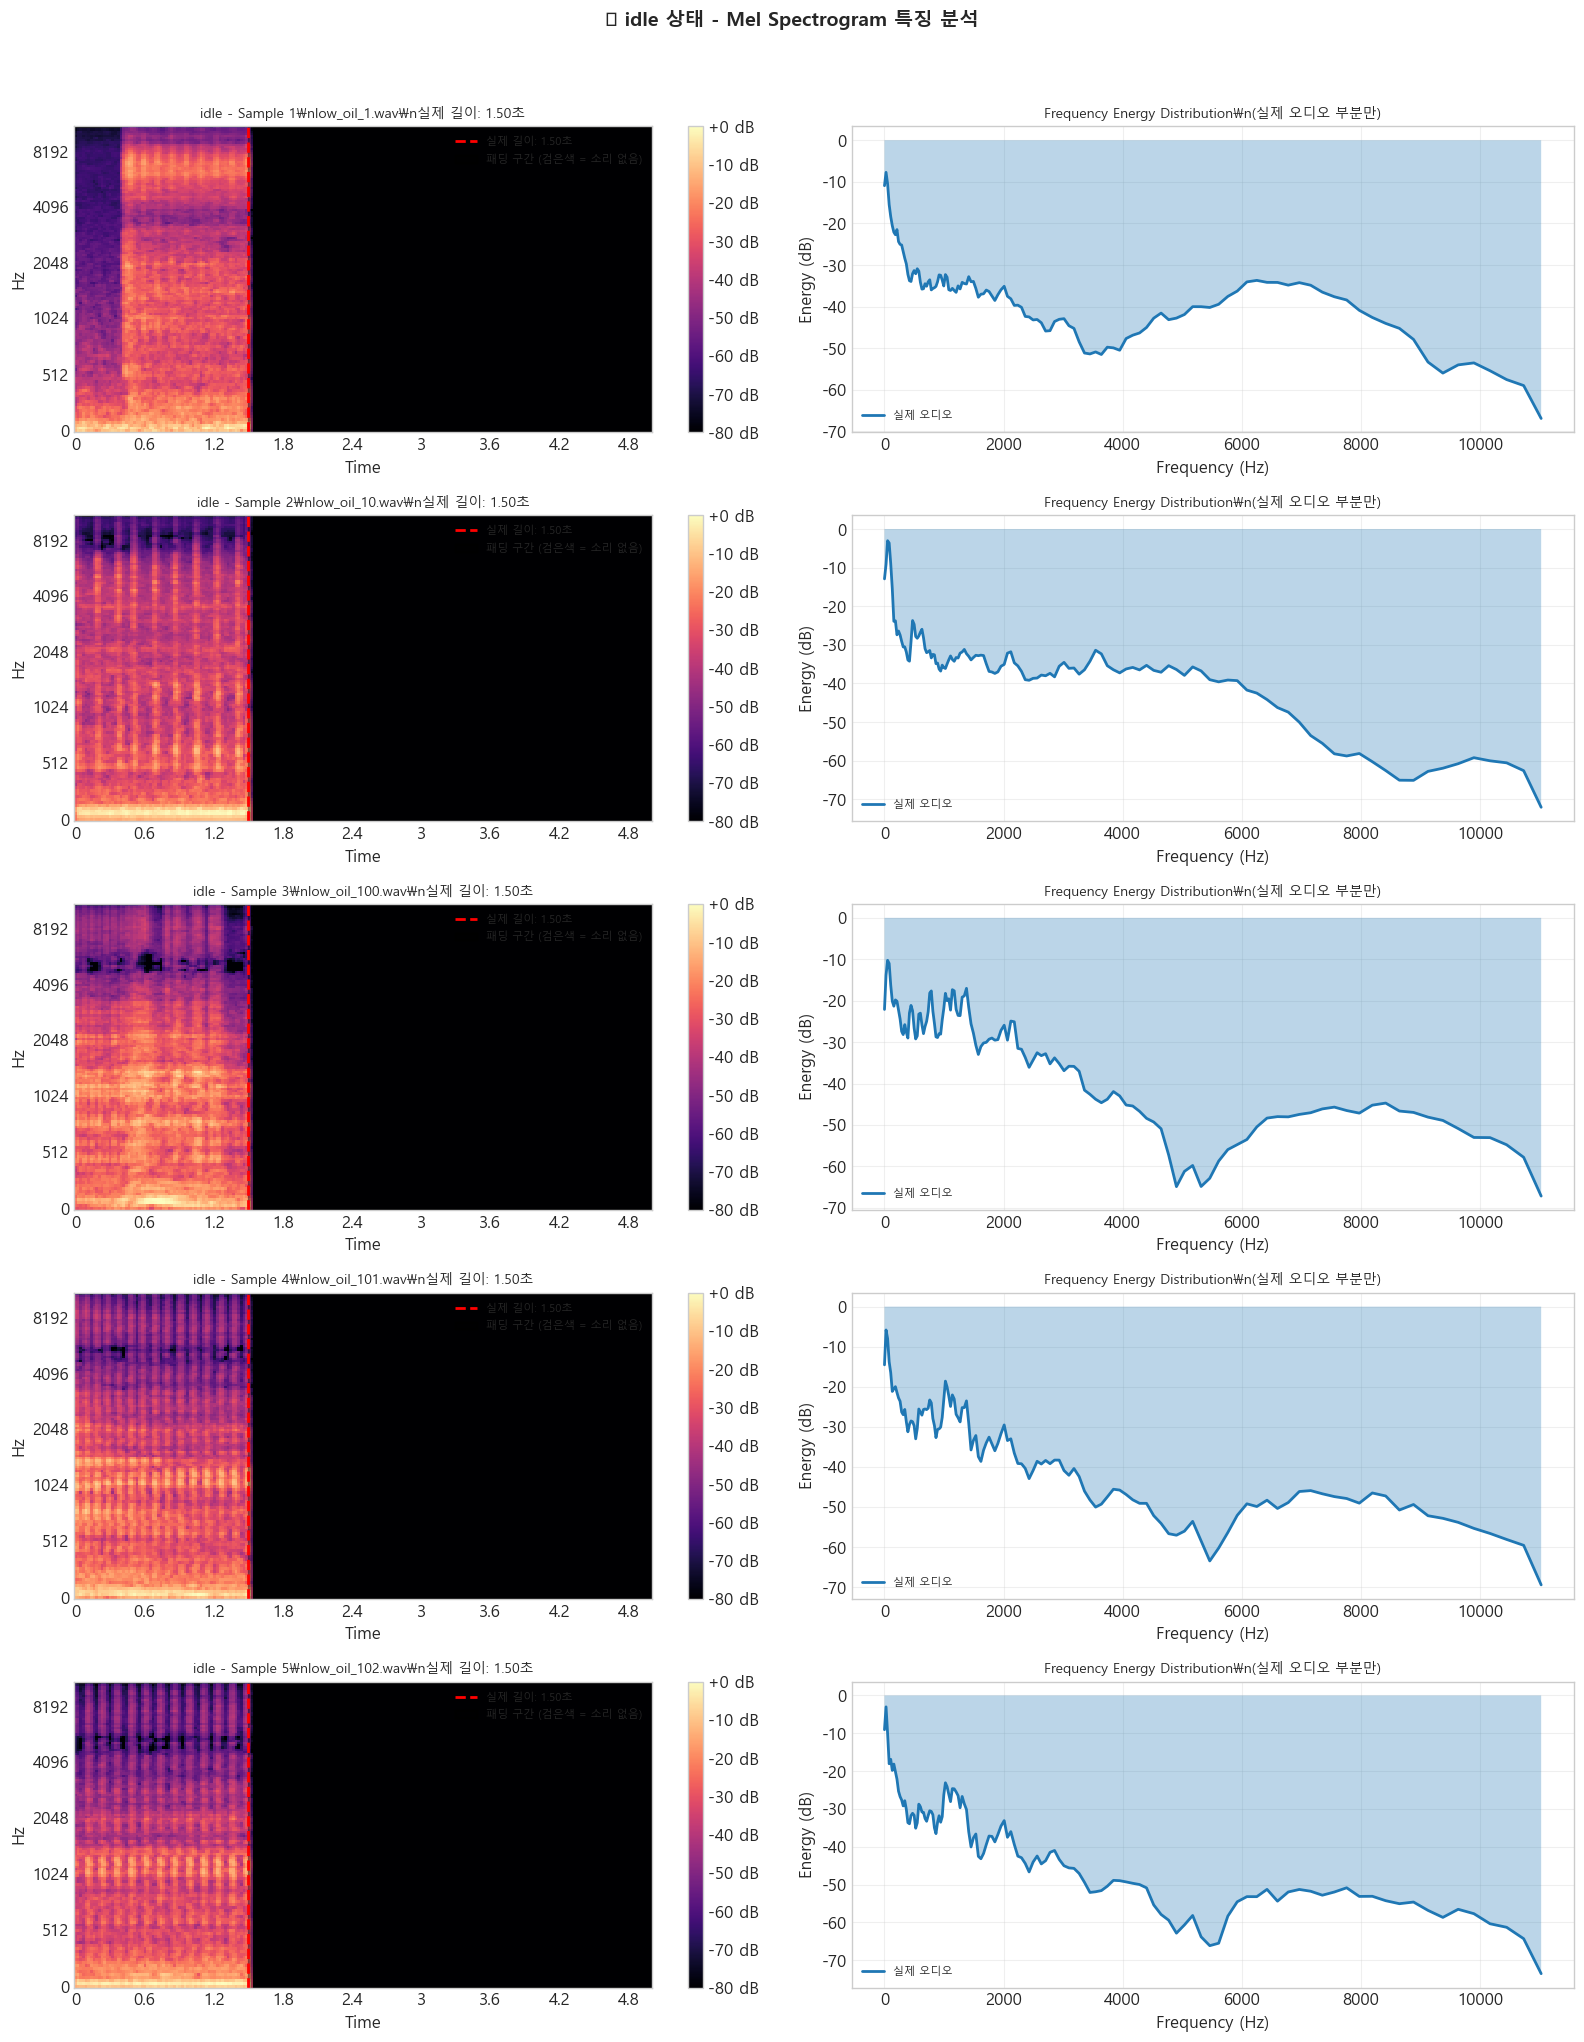


📊 STARTUP 상태 - Mel Spectrogram 특징


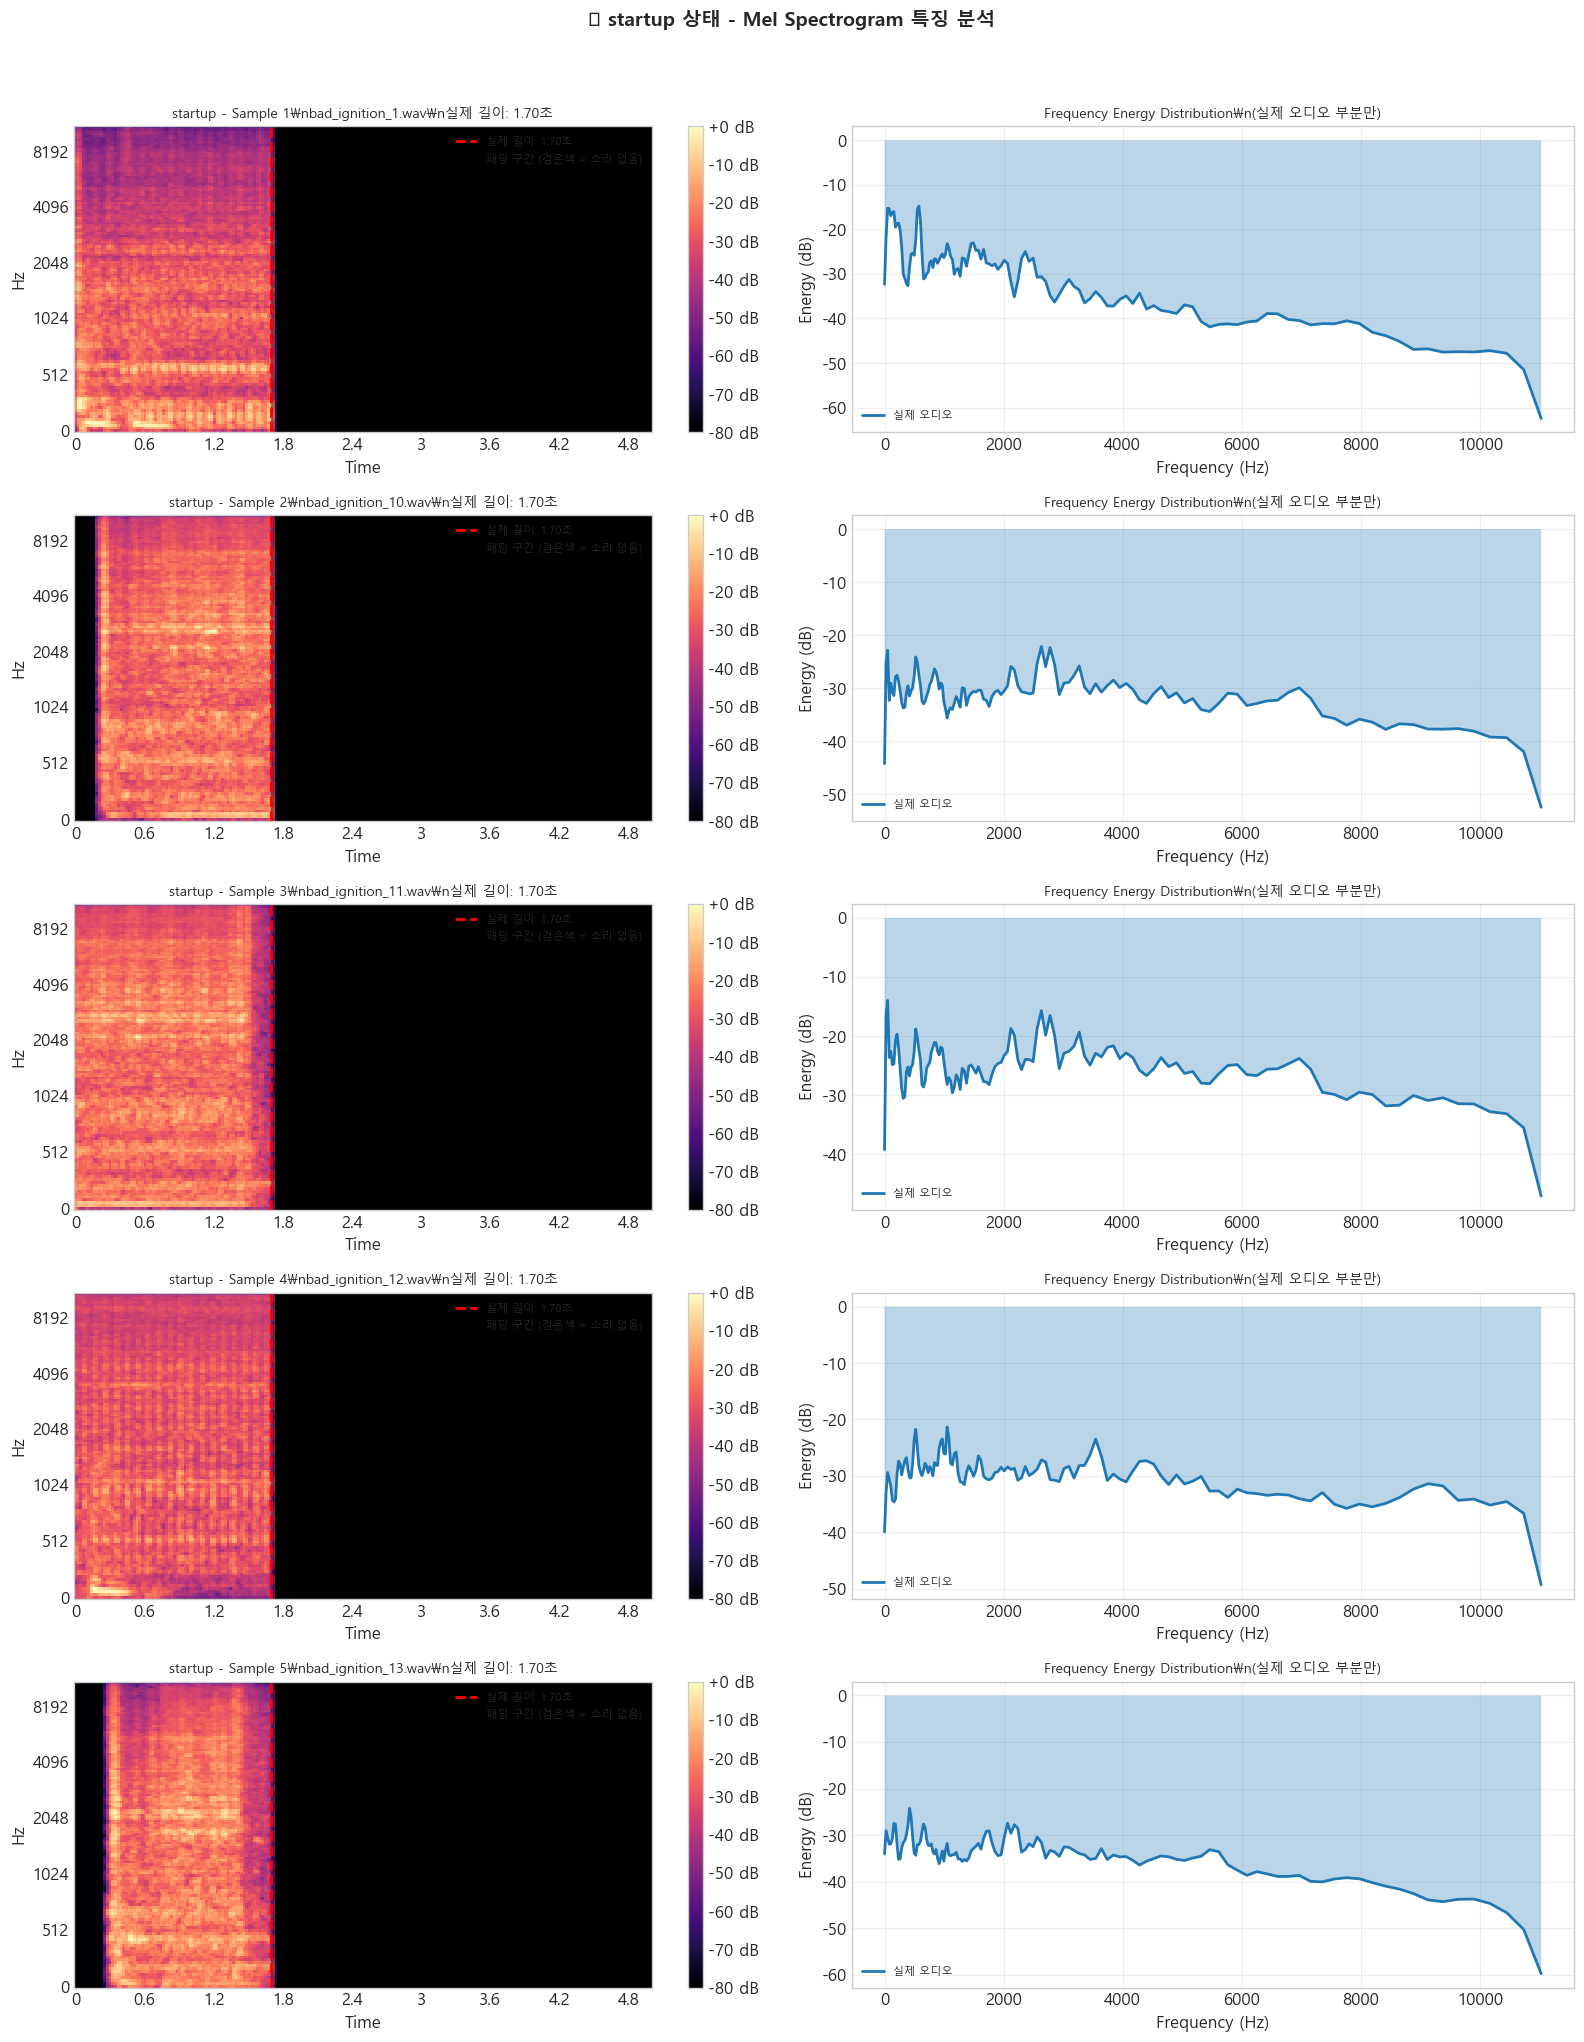

In [3]:
# ============================================================
# 상태별 Mel Spectrogram 특징 시각화
# ============================================================

for state_idx, state_name in enumerate(state_names):
    if state_idx not in state_samples:
        continue
    
    print(f"\n{'='*70}")
    print(f"📊 {state_name.upper()} 상태 - Mel Spectrogram 특징")
    print(f"{'='*70}")
    
    fig, axes = plt.subplots(n_samples_per_state, 2, figsize=(16, 4 * n_samples_per_state))
    if n_samples_per_state == 1:
        axes = axes.reshape(1, -1)
    
    for idx, file_path in enumerate(state_samples[state_idx]):
        # 실제 오디오 길이 확인
        y_original, sr_original = librosa.load(str(file_path), sr=None)
        actual_duration = len(y_original) / sr_original
        
        # 패딩된 오디오 로드
        y, sr = feature_extractor.load_audio(str(file_path))
        mel_spec = feature_extractor.extract_mel_spectrogram(y, sr, to_db=True)
        
        # Mel Spectrogram 시각화
        ax = axes[idx, 0]
        im = librosa.display.specshow(mel_spec, sr=sr, hop_length=audio_config.hop_length,
                                      x_axis='time', y_axis='mel', ax=ax, cmap='magma')
        
        # 패딩 구간 표시
        if actual_duration < audio_config.duration:
            ax.axvline(x=actual_duration, color='red', linestyle='--', linewidth=2,
                      label=f'실제 길이: {actual_duration:.2f}초')
            ax.axvspan(actual_duration, audio_config.duration, alpha=0.3, color='black',
                      label='패딩 구간 (검은색 = 소리 없음)')
        
        ax.set_title(f'{state_name} - Sample {idx+1}\\n{file_path.name}\\n실제 길이: {actual_duration:.2f}초', 
                    fontsize=10)
        plt.colorbar(im, ax=ax, format='%+2.0f dB')
        if actual_duration < audio_config.duration:
            ax.legend(fontsize=8, loc='upper right')
        
        # 주파수 밴드별 평균 에너지 (실제 오디오 부분만)
        ax = axes[idx, 1]
        
        # 실제 오디오 부분의 시간 프레임 계산
        time_frames = mel_spec.shape[1]
        actual_time_frames = int(actual_duration * sr / audio_config.hop_length)
        actual_time_frames = min(actual_time_frames, time_frames)
        
        if actual_time_frames > 0:
            # 실제 오디오 부분만 사용
            freq_energy = np.mean(mel_spec[:, :actual_time_frames], axis=1)
        else:
            freq_energy = np.mean(mel_spec, axis=1)
        
        mel_freqs = librosa.mel_frequencies(n_mels=audio_config.n_mels, fmin=0, fmax=sr/2)
        ax.plot(mel_freqs, freq_energy, linewidth=2, label='실제 오디오')
        ax.fill_between(mel_freqs, 0, freq_energy, alpha=0.3)
        ax.set_title(f'Frequency Energy Distribution\\n(실제 오디오 부분만)', fontsize=10)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Energy (dB)')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    
    plt.suptitle(f'🎵 {state_name} 상태 - Mel Spectrogram 특징 분석', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


---
## 3. 앙상블 모델 (Vote 방식) 및 사용 예시

**참고:** 실제 학습 코드는 별도로 구현하거나 기존 노트북을 참고하세요.

이 섹션에서는 앙상블 모델의 구조와 Vote 방식을 설명합니다.


In [4]:
# ============================================================
# 앙상블 모델 클래스 (Vote 방식)
# ============================================================

class EnsembleVoteModel:
    """
    Waveform과 Mel Spectrogram 모델을 Vote 방식으로 결합
    """
    
    def __init__(
        self,
        waveform_model: nn.Module,
        spectrogram_model: nn.Module,
        device: torch.device,
        vote_method: str = 'soft'  # 'hard' or 'soft'
    ):
        self.waveform_model = waveform_model
        self.spectrogram_model = spectrogram_model
        self.device = device
        self.vote_method = vote_method
        
        # 모델을 eval 모드로 설정
        self.waveform_model.eval()
        self.spectrogram_model.eval()
    
    def predict(self, waveform_input, spectrogram_input):
        """
        두 모델의 예측을 결합
        
        Args:
            waveform_input: Waveform 텐서 (batch, 1, length)
            spectrogram_input: Mel Spectrogram 텐서 (batch, 1, H, W)
        
        Returns:
            ensemble_pred: 앙상블 예측 결과 (batch,)
            ensemble_probs: 앙상블 확률 (batch, num_classes)
            individual_preds: 개별 모델 예측 (dict)
        """
        with torch.no_grad():
            # Waveform 모델 예측
            waveform_output = self.waveform_model(waveform_input.to(self.device))
            waveform_probs = F.softmax(waveform_output, dim=1)
            waveform_pred = waveform_output.argmax(dim=1)
            
            # Mel Spectrogram 모델 예측
            spec_output = self.spectrogram_model(spectrogram_input.to(self.device))
            spec_probs = F.softmax(spec_output, dim=1)
            spec_pred = spec_output.argmax(dim=1)
            
            # Vote 방식에 따라 결합
            if self.vote_method == 'hard':
                # Hard Voting: 다수결
                ensemble_pred = torch.stack([waveform_pred, spec_pred], dim=1)
                ensemble_pred = torch.mode(ensemble_pred, dim=1)[0]
                
                # 확률은 평균
                ensemble_probs = (waveform_probs + spec_probs) / 2
            
            else:  # soft voting
                # Soft Voting: 확률 평균 후 argmax
                ensemble_probs = (waveform_probs + spec_probs) / 2
                ensemble_pred = ensemble_probs.argmax(dim=1)
            
            individual_preds = {
                'waveform': waveform_pred.cpu().numpy(),
                'spectrogram': spec_pred.cpu().numpy(),
                'waveform_probs': waveform_probs.cpu().numpy(),
                'spectrogram_probs': spec_probs.cpu().numpy()
            }
            
            return ensemble_pred.cpu().numpy(), ensemble_probs.cpu().numpy(), individual_preds

print("✅ EnsembleVoteModel 클래스 정의 완료!")
print("\n💡 사용 방법:")
print("  1. Waveform 모델과 Mel Spectrogram 모델을 각각 학습")
print("  2. 두 모델을 EnsembleVoteModel로 결합")
print("  3. predict() 메서드로 앙상블 예측 수행")
print("  4. vote_method='soft' (확률 평균) 또는 'hard' (다수결) 선택 가능")


✅ EnsembleVoteModel 클래스 정의 완료!

💡 사용 방법:
  1. Waveform 모델과 Mel Spectrogram 모델을 각각 학습
  2. 두 모델을 EnsembleVoteModel로 결합
  3. predict() 메서드로 앙상블 예측 수행
  4. vote_method='soft' (확률 평균) 또는 'hard' (다수결) 선택 가능


---
## 4. Waveform 1D CNN 모델 구조 (참고)

**참고:** 실제 학습은 별도로 진행하세요.


In [5]:
# ============================================================
# Waveform 기반 1D CNN 모델 구조 (참고용)
# ============================================================

class WaveformCNN1D(nn.Module):
    """
    Waveform을 입력으로 받는 1D CNN 모델
    """
    
    def __init__(
        self,
        num_classes: int,
        input_length: int = 110250,  # 5초 @ 22050 Hz
        base_channels: int = 64,
        dropout: float = 0.3
    ):
        super().__init__()
        
        self.num_classes = num_classes
        
        # 1D Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, base_channels, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv1d(base_channels, base_channels * 2, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv1d(base_channels * 2, base_channels * 4, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2),
            nn.Dropout(dropout / 2)
        )
        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # Fully connected layers
        self.fc1 = nn.Sequential(
            nn.Linear(base_channels * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        
        self.fc_out = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # x: (batch, 1, length)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc_out(x)
        return x

print("✅ WaveformCNN1D 모델 구조 정의 완료!")
print("\n📊 모델 구조:")
print("  Input: (batch, 1, 110250)  # 5초 @ 22050 Hz")
print("  Conv1 → Conv2 → Conv3 → Global Pooling → FC1 → FC2 → Output")
print("\n💡 Mel Spectrogram 모델은 기존 SoundClassifierCNN을 사용하세요.")


✅ WaveformCNN1D 모델 구조 정의 완료!

📊 모델 구조:
  Input: (batch, 1, 110250)  # 5초 @ 22050 Hz
  Conv1 → Conv2 → Conv3 → Global Pooling → FC1 → FC2 → Output

💡 Mel Spectrogram 모델은 기존 SoundClassifierCNN을 사용하세요.


---
## 5. 오디오 길이 분석 및 패딩 확인

**중요:** 2초 이후가 검은색이면 해당 구간은 **패딩(0으로 채워진 부분)**입니다.
- 실제 오디오가 2초인데 설정된 duration이 5초이면, 나머지 3초는 0으로 패딩됩니다.
- Mel Spectrogram에서 패딩된 부분은 에너지가 0이므로 검은색으로 표시됩니다.


📊 오디오 파일 길이 분석 중...


100%|██████████| 100/100 [00:01<00:00, 69.47it/s]



📈 오디오 길이 통계:
  • 총 샘플: 100개
  • 평균 길이: 1.50초
  • 최소 길이: 1.50초
  • 최대 길이: 1.50초
  • 표준편차: 0.00초
  • 설정된 duration: 5.0초

⚠️ 패딩이 필요한 파일: 100개 (100.0%)
   → 이 파일들은 5.0초로 맞추기 위해 0으로 패딩됩니다.
   → Mel Spectrogram에서 패딩된 부분은 검은색으로 표시됩니다.


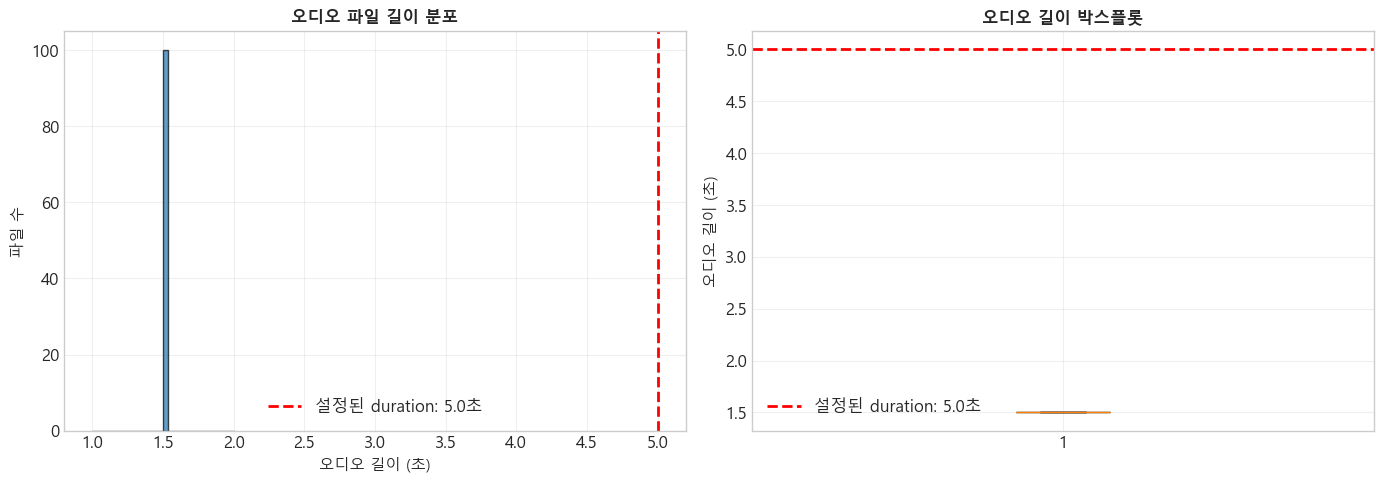


💡 해석:
  • 빨간 점선보다 짧은 파일들은 패딩이 필요합니다.
  • 패딩된 부분은 Mel Spectrogram에서 검은색으로 표시됩니다.
  • 이는 실제 소리가 없는 부분이므로, 모델 학습 시 주의가 필요합니다.


In [6]:
# ============================================================
# 오디오 파일들의 실제 길이 분석
# ============================================================

import librosa

print("📊 오디오 파일 길이 분석 중...")
print("=" * 70)

durations = []
for file_path in tqdm(all_files[:100]):  # 처음 100개만 샘플링
    try:
        y, sr = librosa.load(str(file_path), sr=None)
        duration = len(y) / sr
        durations.append(duration)
    except:
        continue

durations = np.array(durations)

print(f"\n📈 오디오 길이 통계:")
print(f"  • 총 샘플: {len(durations)}개")
print(f"  • 평균 길이: {np.mean(durations):.2f}초")
print(f"  • 최소 길이: {np.min(durations):.2f}초")
print(f"  • 최대 길이: {np.max(durations):.2f}초")
print(f"  • 표준편차: {np.std(durations):.2f}초")
print(f"  • 설정된 duration: {audio_config.duration}초")

# 패딩이 필요한 파일 비율
needs_padding = np.sum(durations < audio_config.duration)
print(f"\n⚠️ 패딩이 필요한 파일: {needs_padding}개 ({100*needs_padding/len(durations):.1f}%)")
print(f"   → 이 파일들은 {audio_config.duration}초로 맞추기 위해 0으로 패딩됩니다.")
print(f"   → Mel Spectrogram에서 패딩된 부분은 검은색으로 표시됩니다.")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 길이 분포 히스토그램
ax = axes[0]
ax.hist(durations, bins=30, alpha=0.7, edgecolor='black')
ax.axvline(audio_config.duration, color='red', linestyle='--', linewidth=2, 
          label=f'설정된 duration: {audio_config.duration}초')
ax.set_xlabel('오디오 길이 (초)', fontsize=11)
ax.set_ylabel('파일 수', fontsize=11)
ax.set_title('오디오 파일 길이 분포', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# 2. 박스플롯
ax = axes[1]
bp = ax.boxplot(durations, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax.axhline(audio_config.duration, color='red', linestyle='--', linewidth=2,
          label=f'설정된 duration: {audio_config.duration}초')
ax.set_ylabel('오디오 길이 (초)', fontsize=11)
ax.set_title('오디오 길이 박스플롯', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n💡 해석:")
print("  • 빨간 점선보다 짧은 파일들은 패딩이 필요합니다.")
print("  • 패딩된 부분은 Mel Spectrogram에서 검은색으로 표시됩니다.")
print("  • 이는 실제 소리가 없는 부분이므로, 모델 학습 시 주의가 필요합니다.")
